# Phase clustering

kmeans and kmedioids analysis

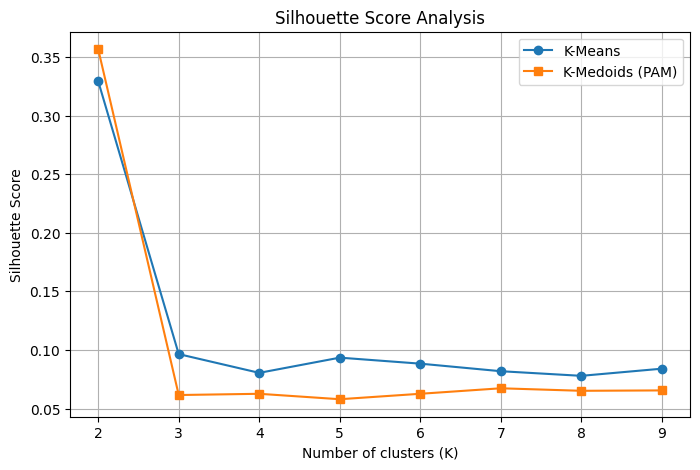

In [4]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0] 
sys.path.append(str(PROJECT_ROOT))


data_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2.csv'
save_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2_clustered.csv'

# 1. Load data
df = pd.read_csv(data_path)

cols_to_drop = ['original ID', 'raw_data Path', 'Team ID', 'Individual', 'phase']
features_raw = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

features = features_raw.select_dtypes(include=[np.number])
features = features.fillna(features.median())

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 3. Find optimal K using Silhouette Score
k_range = range(2, 10)
kmeans_scores = []
kmedoids_scores = []

for k in k_range:
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_labels = kmeans.fit_predict(X_scaled)
    kmeans_scores.append(silhouette_score(X_scaled, k_labels))
    
    # K-Medoids (PAM algorithm)
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam')
    m_labels = kmedoids.fit_predict(X_scaled)
    kmedoids_scores.append(silhouette_score(X_scaled, m_labels))

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, kmeans_scores, marker='o', label='K-Means')
plt.plot(k_range, kmedoids_scores, marker='s', label='K-Medoids (PAM)')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

# 4. Fit final models
best_k = 2

df['KMeans_Cluster'] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_scaled)
df['KMedoids_Cluster'] = KMedoids(n_clusters=best_k, random_state=42, method='pam').fit_predict(X_scaled)

# Save results
df.to_csv(save_path, index=False)

Validation of the clustering: not useful

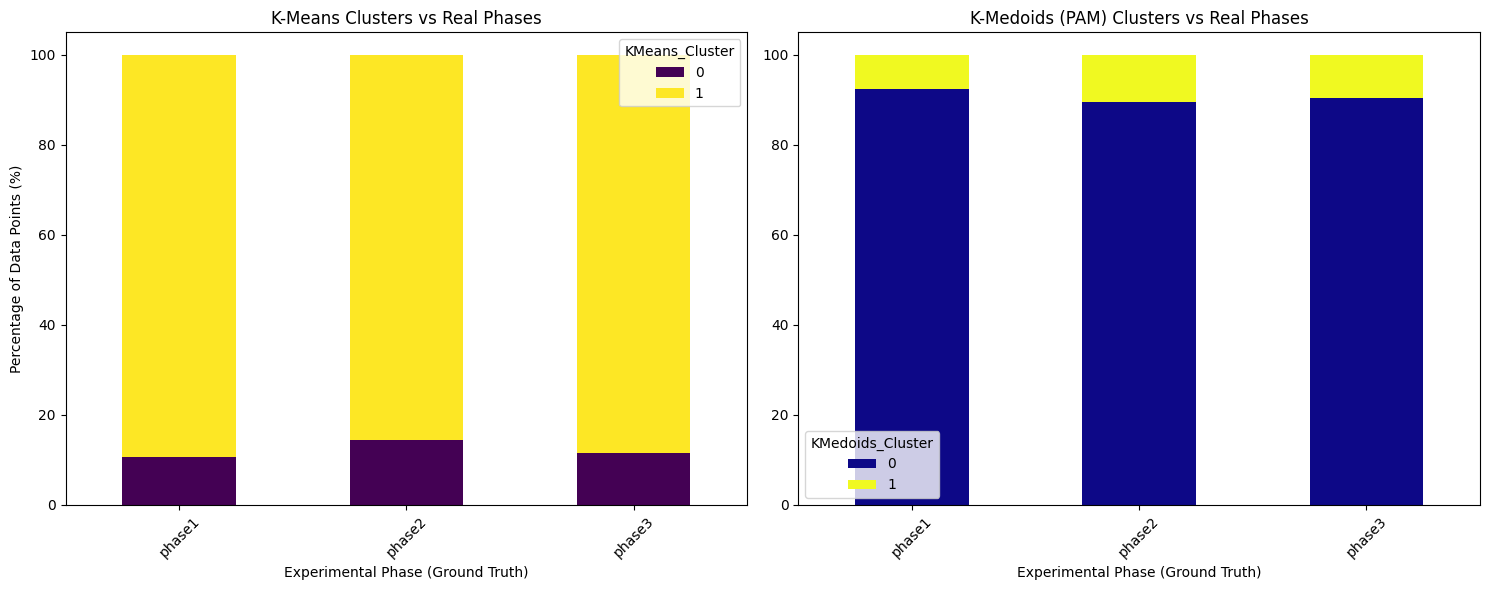

--- Absolute counts: K-Means vs Phases ---
KMeans_Cluster   0   1
Phase                 
phase1          11  93
phase2          15  89
phase3          12  92

--- Absolute counts: K-Medoids vs Phases ---
KMedoids_Cluster   0   1
Phase                   
phase1            96   8
phase2            93  11
phase3            94  10


In [5]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0] 
sys.path.append(str(PROJECT_ROOT))

data_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2_clustered.csv'

df = pd.read_csv(data_path)

if 'Phase' in df.columns:
    col_phase = 'Phase'
elif 'phase' in df.columns:
    col_phase = 'phase'

kmeans_ct = pd.crosstab(df[col_phase], df['KMeans_Cluster'], normalize='index') * 100
kmedoids_ct = pd.crosstab(df[col_phase], df['KMedoids_Cluster'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

kmeans_ct.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0])
axes[0].set_title('K-Means Clusters vs Real Phases')
axes[0].set_xlabel('Experimental Phase (Ground Truth)')
axes[0].set_ylabel('Percentage of Data Points (%)')
axes[0].tick_params(axis='x', rotation=45)

kmedoids_ct.plot(kind='bar', stacked=True, colormap='plasma', ax=axes[1])
axes[1].set_title('K-Medoids (PAM) Clusters vs Real Phases')
axes[1].set_xlabel('Experimental Phase (Ground Truth)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("--- Absolute counts: K-Means vs Phases ---")
print(pd.crosstab(df[col_phase], df['KMeans_Cluster']))
print("\n--- Absolute counts: K-Medoids vs Phases ---")
print(pd.crosstab(df[col_phase], df['KMedoids_Cluster']))


Introducing basic PCA before clustering

Variance explained by 5 PC: 49.57%


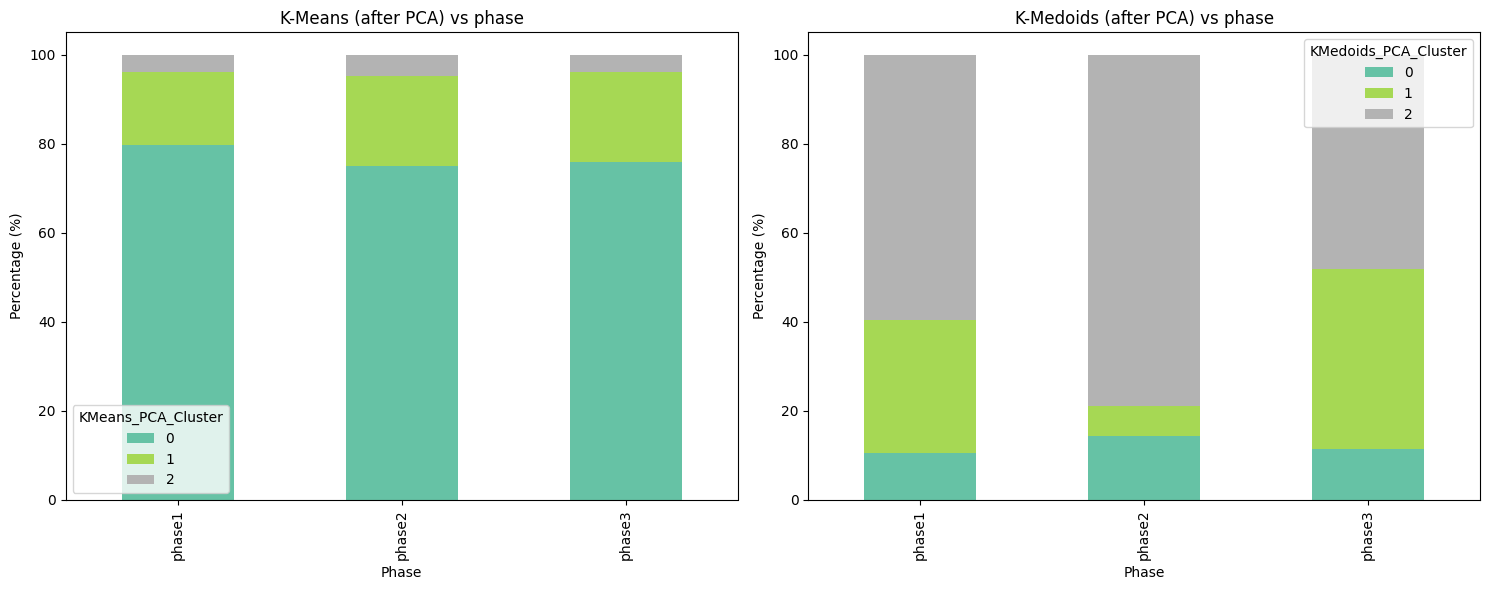


--- Does the clustering depend on the ROLE? ---
KMeans_PCA_Cluster    0   1   2
Puzzler                        
0                   120  35   1
1                   120  24  12


In [6]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0] 
sys.path.append(str(PROJECT_ROOT))
data_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2.csv'

df = pd.read_csv(data_path)
meta_cols = ['original ID', 'raw_data Path', 'Team ID', 'Individual', 'Phase', 'phase', 'Round', 'Puzzler', 'Cohort']
numeric_cols = df.select_dtypes(include='number').columns.tolist()
biosignal_cols = [c for c in numeric_cols if c not in meta_cols]

# Scaling based on individual subjects
X = df[biosignal_cols].fillna(df[biosignal_cols].median())
X_scaled = StandardScaler().fit_transform(X)

# PCA dimensionality reduction
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 5 PC: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

# clustering on PCA components
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_PCA_Cluster'] = kmeans.fit_predict(X_pca)

kmedoids = KMedoids(n_clusters=best_k, random_state=42, method='pam')
df['KMedoids_PCA_Cluster'] = kmedoids.fit_predict(X_pca)

col_phase = 'Phase' if 'Phase' in df.columns else 'phase'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

kmeans_ct = pd.crosstab(df[col_phase], df['KMeans_PCA_Cluster'], normalize='index') * 100
kmeans_ct.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0])
axes[0].set_title('K-Means (after PCA) vs phase')
axes[0].set_ylabel('Percentage (%)')

kmedoids_ct = pd.crosstab(df[col_phase], df['KMedoids_PCA_Cluster'], normalize='index') * 100
kmedoids_ct.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('K-Medoids (after PCA) vs phase')
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

if 'Puzzler' in df.columns:
    print("\n--- ""Does the clustering depend on the ROLE? ---")
    print(pd.crosstab(df['Puzzler'], df['KMeans_PCA_Cluster']))

Introducing individual standardization and gmm

Explained Variance (5 PCs) with per-subject scaling: 45.81%


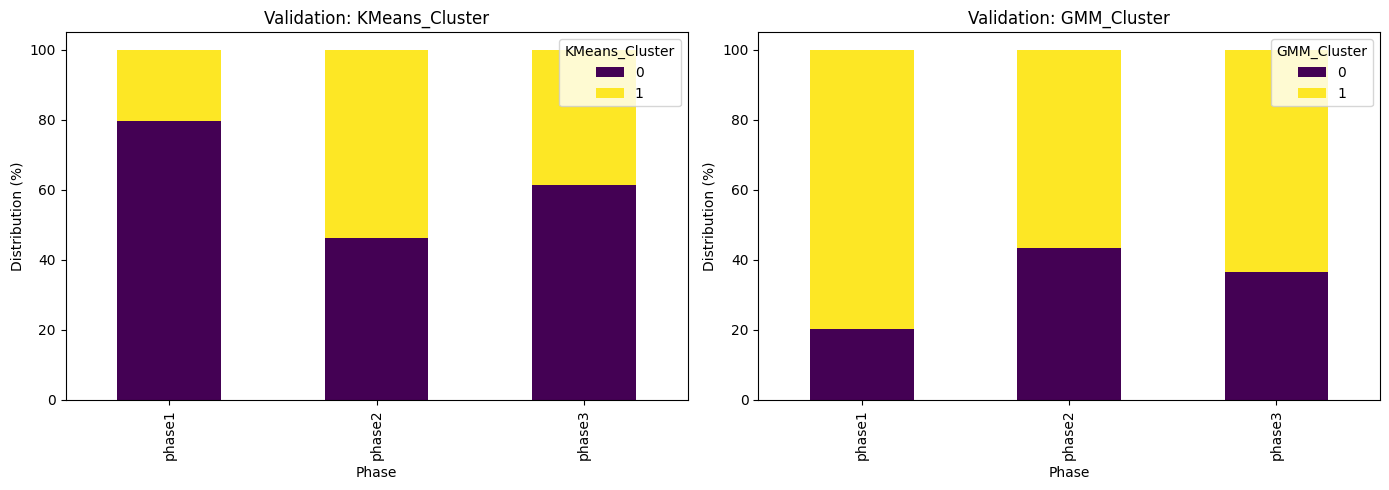


--- Phase Distribution in GMM Clusters ---
GMM_Cluster   0   1
Phase              
phase1       21  83
phase2       45  59
phase3       38  66


C:\Users\aless\AppData\Local\Temp\ipykernel_15876\2988411072.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GMM_Cluster', y=feature, data=df, ax=axes[i], palette='Set2')
C:\Users\aless\AppData\Local\Temp\ipykernel_15876\2988411072.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GMM_Cluster', y=feature, data=df, ax=axes[i], palette='Set2')


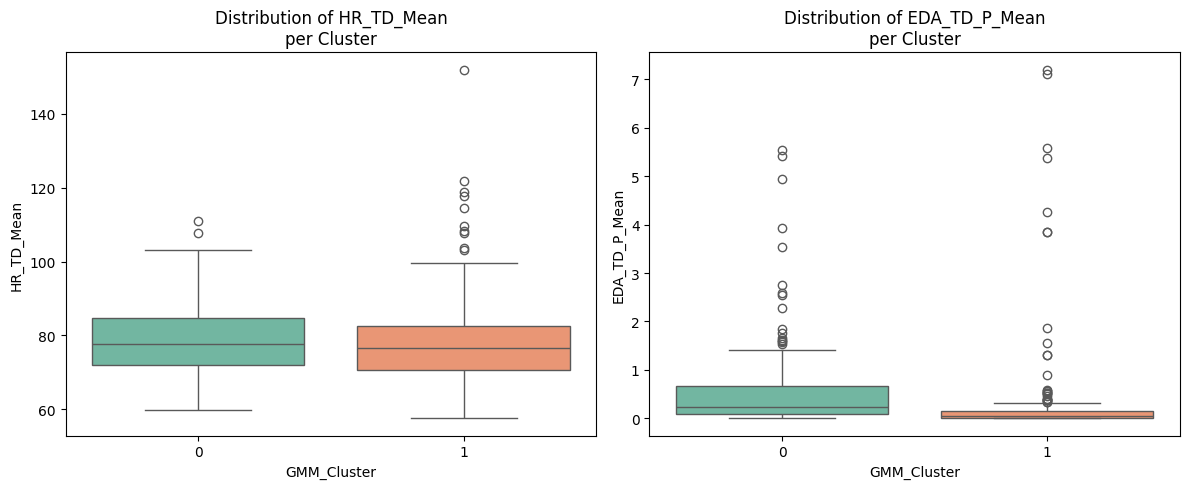


--- Statistical Analysis ---
Chi-Square Test P-value: 0.00137


In [9]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0] 
sys.path.append(str(PROJECT_ROOT)) 
data_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2.csv'
save_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_results_pca_kmean_gmm.csv'

# 1. Load Data
df = pd.read_csv(data_path)

# Identification of biosignal columns (excluding metadata)
meta_cols = ['original ID', 'raw_data Path', 'Team ID', 'Individual', 'Phase', 'phase', 'Round', 'Puzzler', 'Cohort']
biosignal_cols = [c for c in df.select_dtypes(include='number').columns if c not in meta_cols]

# 2. SECRET WEAPON: Per-Subject Standardization
# This removes baseline differences between individuals
X_scaled_list = []
for person in df['Individual'].unique():
    mask = df['Individual'] == person
    person_data = df.loc[mask, biosignal_cols].fillna(df[biosignal_cols].median())
    scaler = StandardScaler()
    X_scaled_list.append(scaler.fit_transform(person_data))

X_per_subject = np.vstack(X_scaled_list)

# 3. Dimensionality Reduction (PCA)
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_per_subject)
print(f"Explained Variance (5 PCs) with per-subject scaling: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# 4. Clustering: KMeans vs GMM (K=2)
# GMM is more flexible than KMeans for biosignal data
k = 2
df['KMeans_Cluster'] = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca)
df['GMM_Cluster'] = GaussianMixture(n_components=k, random_state=42).fit_predict(X_pca)

# 5. Validation with Experimental Phases
col_phase = 'Phase' if 'Phase' in df.columns else 'phase'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, model in enumerate(['KMeans_Cluster', 'GMM_Cluster']):
    ct = pd.crosstab(df[col_phase], df[model], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'Validation: {model}')
    axes[i].set_ylabel('Distribution (%)')

plt.tight_layout()
plt.show()

# 6. Saving and final check
df.to_csv(save_path, index=False)
print("\n--- Phase Distribution in GMM Clusters ---")
print(pd.crosstab(df[col_phase], df['GMM_Cluster']))

# Feature boxplots for cluster interpretation
features_to_plot = ['HR_TD_Mean', 'EDA_TD_P_Mean'] 

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(12, 5))
for i, feature in enumerate(features_to_plot):
    if feature in df.columns:
        sns.boxplot(x='GMM_Cluster', y=feature, data=df, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Distribution of {feature}\nper Cluster')
    else:
        print(f"Warning: column {feature} not found.")

plt.tight_layout()
plt.show()

# Statistical Analysis (Chi-Square Test)
contingency_table = pd.crosstab(df[col_phase], df['GMM_Cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n--- Statistical Analysis ---")
print(f"Chi-Square Test P-value: {p:.5f}")

UMAP instead of pca

c:\Users\aless\OneDrive\Documenti\Computational data analysis\cda-case-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating UMAP... (this might take a few seconds)


c:\Users\aless\OneDrive\Documenti\Computational data analysis\cda-case-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Chi-Square P-Value (UMAP+GMM): 0.00000 ---


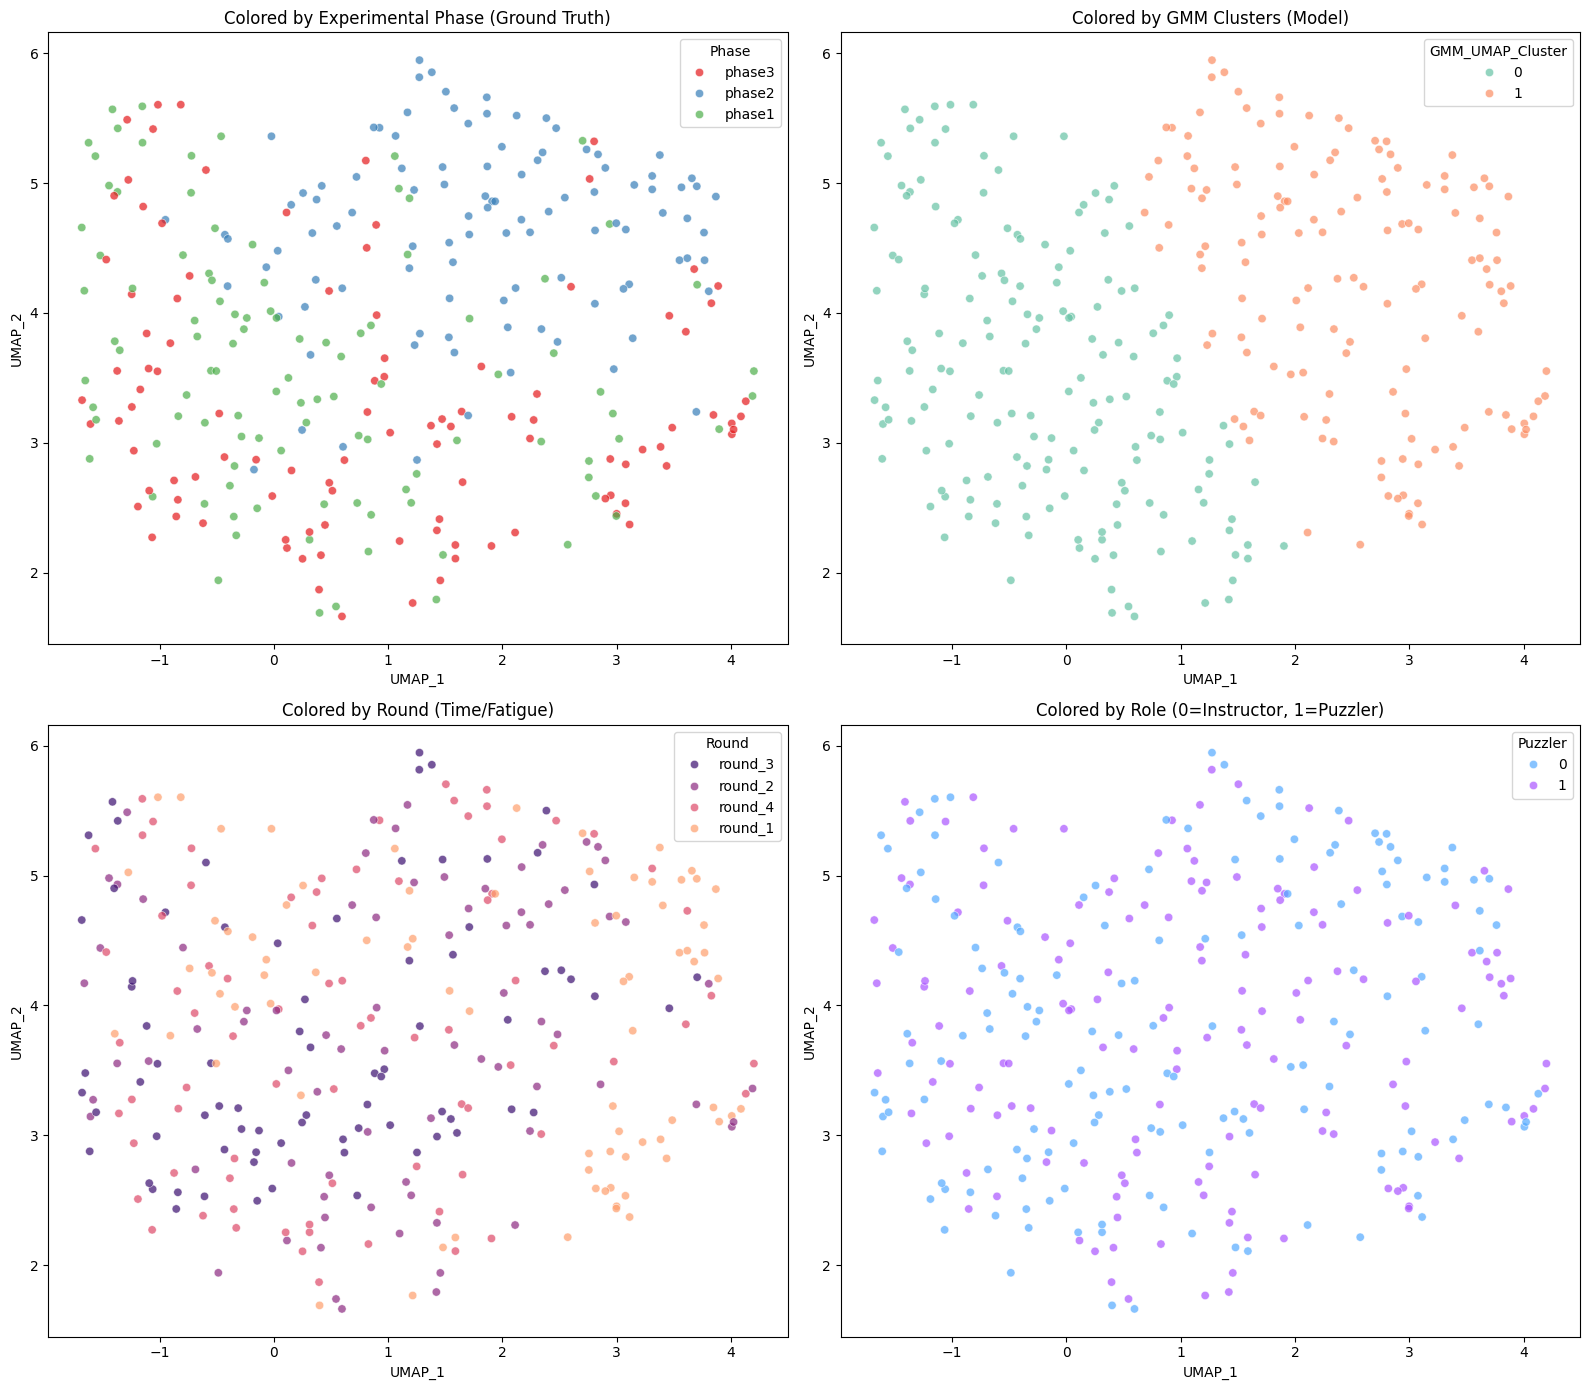


--- Numbers behind the P-Value: ---
GMM_UMAP_Cluster   0   1
Phase                   
phase1            80  24
phase2            22  82
phase3            67  37


In [10]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0] 
sys.path.append(str(PROJECT_ROOT)) 
data_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2.csv'
df = pd.read_csv(data_path)

meta_cols = ['original ID', 'raw_data Path', 'Team ID', 'Individual', 'Phase', 'phase', 'Round', 'Puzzler', 'Cohort']
biosignal_cols = [c for c in df.select_dtypes(include='number').columns if c not in meta_cols]

# 1. PER-SUBJECT SCALING (Your secret weapon)
X_scaled_list = []
for person in df['Individual'].unique():
    mask = df['Individual'] == person
    person_data = df.loc[mask, biosignal_cols].fillna(df[biosignal_cols].median())
    X_scaled_list.append(StandardScaler().fit_transform(person_data))
X_per_subject = np.vstack(X_scaled_list)

# 2. UMAP DIMENSIONALITY REDUCTION (Teammate contribution)
print("Calculating UMAP... (this might take a few seconds)")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_per_subject)
df['UMAP_1'] = X_umap[:, 0]
df['UMAP_2'] = X_umap[:, 1]

# 3. GMM CLUSTERING (K=2) in UMAP space
gmm = GaussianMixture(n_components=2, random_state=42)
df['GMM_UMAP_Cluster'] = gmm.fit_predict(X_umap)

col_phase = 'Phase' if 'Phase' in df.columns else 'phase'

# 4. STATISTICS (Chi-Square Test)
ct = pd.crosstab(df[col_phase], df['GMM_UMAP_Cluster'])
_, p, _, _ = chi2_contingency(ct)
print(f"\n--- Chi-Square P-Value (UMAP+GMM): {p:.5f} ---")

# 5. INVESTIGATIVE 4-PANEL VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Phases
sns.scatterplot(x='UMAP_1', y='UMAP_2', hue=col_phase, data=df, ax=axes[0,0], palette='Set1', alpha=0.7)
axes[0,0].set_title('Colored by Experimental Phase (Ground Truth)')

# Plot 2: GMM Clusters
sns.scatterplot(x='UMAP_1', y='UMAP_2', hue='GMM_UMAP_Cluster', data=df, ax=axes[0,1], palette='Set2', alpha=0.7)
axes[0,1].set_title('Colored by GMM Clusters (Model)')

# Plot 3: Round (Time/Fatigue)
if 'Round' in df.columns:
    sns.scatterplot(x='UMAP_1', y='UMAP_2', hue='Round', data=df, ax=axes[1,0], palette='magma', alpha=0.7)
    axes[1,0].set_title('Colored by Round (Time/Fatigue)')

# Plot 4: Role (Puzzler vs Instructor)
if 'Puzzler' in df.columns:
    sns.scatterplot(x='UMAP_1', y='UMAP_2', hue='Puzzler', data=df, ax=axes[1,1], palette='cool', alpha=0.7)
    axes[1,1].set_title('Colored by Role (0=Instructor, 1=Puzzler)')

plt.tight_layout()
plt.show()

# Print the cross-tabulation table to inspect differences
print("\n--- Numbers behind the P-Value: ---")
print(pd.crosstab(df[col_phase], df['GMM_UMAP_Cluster']))

Now we see that there are two distinguished zones: stressed vs relaxed

Now trying preprocessing with sparse PCA


--- SENSORS DRIVING THE CLUSTERS (Interpretation) ---

PC1 is composed of 25 features:
EDA_TD_P_Max          0.354953
EDA_TD_P_std          0.341988
EDA_TD_P_Slope_min   -0.334994
Name: PC1, dtype: float64

PC2 is composed of 16 features:
HR_TD_Max     0.476334
HR_TD_Mean    0.422322
HR_TD_std     0.363823
Name: PC2, dtype: float64

PC3 is composed of 15 features:
TEMP_TD_Mean      0.490920
TEMP_TD_Median    0.489764
TEMP_TD_Min       0.484878
Name: PC3, dtype: float64

PC4 is composed of 36 features:
EDA_TD_P_Peaks       0.400125
EDA_TD_P_Skew       -0.361420
EDA_TD_P_Kurtosis   -0.336888
Name: PC4, dtype: float64

PC5 is composed of 21 features:
EDA_TD_T_Mean      0.457869
EDA_TD_T_AUC       0.444245
EDA_TD_T_Median    0.441247
Name: PC5, dtype: float64

--- Chi-Square Test P-Value (SPCA+GMM): 0.01165 ---

Distribution:
GMM_SPCA_Cluster   0   1
Phase                   
phase1            24  80
phase2            43  61
phase3            40  64


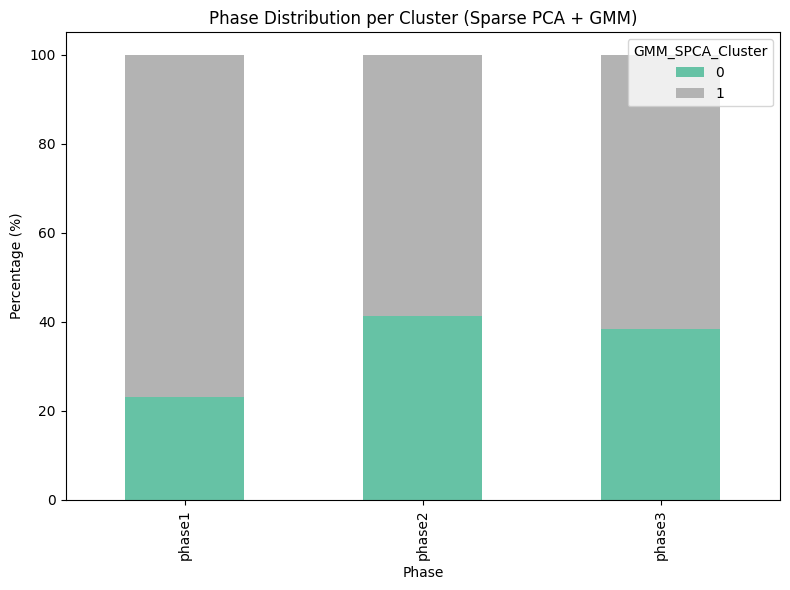


--- Deep Analysis: Who is getting stressed? ---

[PUZZLER] (Active players):
GMM_SPCA_Cluster   0   1
Phase                   
phase1            14  38
phase2            16  36
phase3            20  32

[INSTRUCTOR] (Passive observers):
GMM_SPCA_Cluster   0   1
Phase                   
phase1            10  42
phase2            27  25
phase3            20  32


In [11]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import SparsePCA
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0] 
sys.path.append(str(PROJECT_ROOT)) 
data_path = PROJECT_ROOT / 'data' / 'processed' / 'HR_data_2.csv'
df = pd.read_csv(data_path)

meta_cols = ['original ID', 'raw_data Path', 'Team ID', 'Individual', 'Phase', 'phase', 'Round', 'Puzzler', 'Cohort']
questionnaire_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
biosignal_cols = [c for c in df.select_dtypes(include='number').columns if c not in meta_cols and c not in questionnaire_cols]

# 1. YOUR SIGNATURE METHOD: Per-Subject Scaling
# This removes baseline differences between individuals to focus on task-related changes
X_scaled_list = []
for person in df['Individual'].unique():
    mask = df['Individual'] == person
    person_data = df.loc[mask, biosignal_cols].fillna(df[biosignal_cols].median())
    X_scaled_list.append(StandardScaler().fit_transform(person_data))
X_per_subject = np.vstack(X_scaled_list)

# 2. SPARSE PCA
# alpha controls the sparsity (higher value forces more features to zero)
n_components = 5
spca = SparsePCA(n_components=n_components, alpha=1.0, random_state=42)
X_spca = spca.fit_transform(X_per_subject)

# 3. INTERPRETABILITY: Identify key sensors driving the clusters
components_df = pd.DataFrame(spca.components_, columns=biosignal_cols, index=[f'PC{i+1}' for i in range(n_components)])
print("\n--- SENSORS DRIVING THE CLUSTERS (Interpretation) ---")
for pc in components_df.index:
    # Select only non-zero features
    survivors = components_df.loc[pc][abs(components_df.loc[pc]) > 1e-4]
    survivors = survivors.sort_values(key=abs, ascending=False)
    print(f"\n{pc} is composed of {len(survivors)} features:")
    print(survivors.head(3)) # Showing top 3 for clarity

# 4. GMM CLUSTERING
gmm = GaussianMixture(n_components=2, random_state=42)
df['GMM_SPCA_Cluster'] = gmm.fit_predict(X_spca)

col_phase = 'Phase' if 'Phase' in df.columns else 'phase'

# 5. VALIDATION (Chi-Square Test)
ct = pd.crosstab(df[col_phase], df['GMM_SPCA_Cluster'])
_, p, _, _ = chi2_contingency(ct)

print(f"\n--- Chi-Square Test P-Value (SPCA+GMM): {p:.5f} ---")
print("\nDistribution:")
print(ct)

# 6. FINAL PLOT
fig, ax = plt.subplots(figsize=(8, 6))
ct_norm = pd.crosstab(df[col_phase], df['GMM_SPCA_Cluster'], normalize='index') * 100
ct_norm.plot(kind='bar', stacked=True, colormap='Set2', ax=ax)
ax.set_title('Phase Distribution per Cluster (Sparse PCA + GMM)')
ax.set_ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

# --- OPTION 7: ANALYSIS BY ROLE ---
if 'Puzzler' in df.columns:
    print("\n--- Deep Analysis: Who is getting stressed? ---")
    # Puzzler = 1 (The person assembling the puzzle)
    puzzler_mask = df['Puzzler'] == 1
    ct_puzzler = pd.crosstab(df[col_phase][puzzler_mask], df['GMM_SPCA_Cluster'][puzzler_mask])
    
    # Instructor = 0 (The person watching and guiding)
    instructor_mask = df['Puzzler'] == 0
    ct_instructor = pd.crosstab(df[col_phase][instructor_mask], df['GMM_SPCA_Cluster'][instructor_mask])
    
    print("\n[PUZZLER] (Active players):")
    print(ct_puzzler)
    print("\n[INSTRUCTOR] (Passive observers):")
    print(ct_instructor)

It identifies the important sensors